In [40]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [41]:
data_logical_filter = pd.read_csv("data/dataset_logical_filter.csv")
data_price_ratio = pd.read_csv("data/dataset_Price_Ratio_.20.csv")
dfLogical = pd.DataFrame(data_logical_filter)
dfPrice = pd.DataFrame(data_price_ratio)
dfLogical

,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0
...,...,...,...,...,...,...,...,...
292,2016,9.50,11.60,33988,Diesel,Dealer,Manual,0
293,2015,4.00,5.90,60000,Petrol,Dealer,Manual,0
294,2009,3.35,11.00,87934,Petrol,Dealer,Manual,0
295,2017,11.50,12.50,9000,Diesel,Dealer,Manual,0


In [42]:
###### Convert categorical text columns into numbers for model training

In [43]:
dfLogical['Fuel_Type'] = dfLogical['Fuel_Type'].map({'Petrol': 0, 'Diesel': 1})
dfLogical['Seller_Type'] = dfLogical['Seller_Type'].map({'Dealer': 0, 'Individual': 1})
dfLogical['Transmission'] = dfLogical['Transmission'].map({'Manual': 0, 'Automatic': 1})
dfLogical.head()

,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,2014,3.35,5.59,27000,0,0,0,0
1,2013,4.75,9.54,43000,1,0,0,0
2,2017,7.25,9.85,6900,0,0,0,0
3,2011,2.85,4.15,5200,0,0,0,0
4,2014,4.60,6.87,42450,1,0,0,0


In [44]:
def train_linear_model(dataframe, target_column):
    X = dataframe.drop(target_column, axis=1)
    y = dataframe[target_column].values.reshape(-1, 1)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)
    model = LinearRegression()
    model.fit(X_train, y_train)
    return model, X_test, y_test

In [45]:
model_logical, X_test_logical, y_test_logical = train_linear_model(dfLogical, 'Selling_Price')

In [46]:
y_pred_logical = model_logical.predict(X_test_logical)

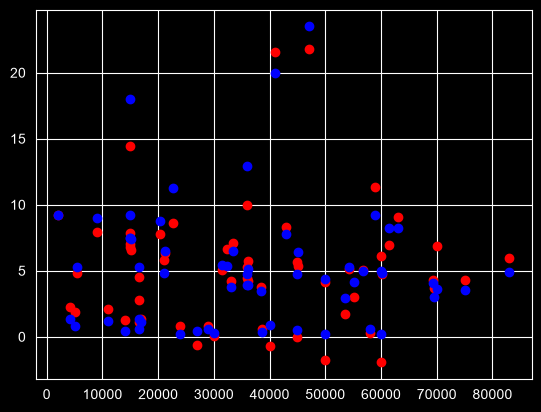

In [47]:
plt.scatter(X_test_logical.Kms_Driven, y_pred_logical, color='red')
plt.scatter(X_test_logical.Kms_Driven, y_test_logical, color='blue')

In [48]:
#######errore and score Logical model

In [49]:
mae = mean_absolute_error(y_test_logical, y_pred_logical)
mse = mean_squared_error(y_test_logical, y_pred_logical)
r2 = r2_score(y_test_logical, y_pred_logical)

print(f"R2 Score: {r2}")
print(f"MAE: {mae}")
print(f"MSE: {mse}")

R2 Score: 0.9293838464914299
MAE: 0.9553701316762669
MSE: 1.5486505733602578


In [50]:
dfPrice = pd.get_dummies(dfPrice, columns=['Fuel_Type', 'Seller_Type'], drop_first=True, dtype=int)

dfPrice['Transmission'] = dfPrice['Transmission'].map({'Manual': 0, 'Automatic': 1})
dfPrice.head()

,Year,Selling_Price,Present_Price,Kms_Driven,Transmission,Owner,Fuel_Type_Petrol,Seller_Type_Individual
0,2014,3.35,5.59,27000,0,0,1,0
1,2013,4.75,9.54,43000,0,0,0,0
2,2017,7.25,9.85,6900,0,0,1,0
3,2011,2.85,4.15,5200,0,0,1,0
4,2014,4.60,6.87,42450,0,0,0,0


In [51]:
model_price, X_test_price, y_test_price = train_linear_model(dfPrice, 'Selling_Price')
y_pred_price = model_price.predict(X_test_price)


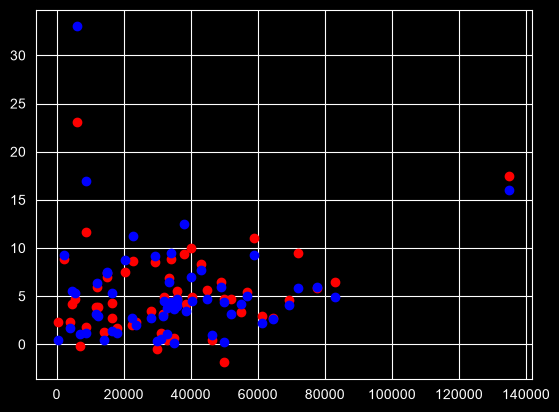

In [52]:
plt.scatter(X_test_price.Kms_Driven, y_pred_price, color='red')
plt.scatter(X_test_price.Kms_Driven, y_test_price, color='blue')

In [53]:
mae = mean_absolute_error(y_test_price, y_pred_price)
mse = mean_squared_error(y_test_price, y_pred_price)
r2 = r2_score(y_test_price, y_pred_price)

print(f"R2 Score: {r2}")
print(f"MAE: {mae}")
print(f"MSE: {mse}")

R2 Score: 0.8672749956311041
MAE: 1.1314682525932163
MSE: 3.47859654837276


I choose model_price, because i think its more accurate than model_logical. now i gonna train model more accurate base on effect of feature

In [54]:
def train_linear_model_X_y(X, y):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)
    model = LinearRegression()
    model.fit(X_train, y_train)
    return model, X_test, y_test

In [55]:
dfPrice['log_Selling_Price'] = np.log(dfPrice['Selling_Price'])
dfPrice

,Year,Selling_Price,Present_Price,Kms_Driven,Transmission,Owner,Fuel_Type_Petrol,Seller_Type_Individual,log_Selling_Price
0,2014,3.35,5.59,27000,0,0,1,0,1.208960
1,2013,4.75,9.54,43000,0,0,0,0,1.558145
2,2017,7.25,9.85,6900,0,0,1,0,1.981001
3,2011,2.85,4.15,5200,0,0,1,0,1.047319
4,2014,4.60,6.87,42450,0,0,0,0,1.526056
...,...,...,...,...,...,...,...,...,...
290,2016,9.50,11.60,33988,0,0,0,0,2.251292
291,2015,4.00,5.90,60000,0,0,1,0,1.386294
292,2009,3.35,11.00,87934,0,0,1,0,1.208960
293,2017,11.50,12.50,9000,0,0,0,0,2.442347


In [56]:
X_exp = dfPrice.drop(['Selling_Price', 'log_Selling_Price'], axis=1)
y_exp = dfPrice['log_Selling_Price'].values.reshape(-1, 1)

In [57]:
model_exp, X_test_exp, y_test_log = train_linear_model_X_y(X_exp, y_exp)
y_pred_log = model_exp.predict(X_test_exp)

In [58]:
y_pred_log_real = np.exp(y_pred_log)
y_test_log_real = np.exp(y_test_log)

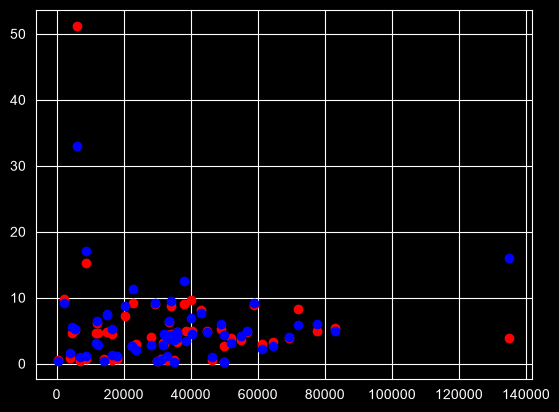

In [59]:
plt.scatter(X_test_exp.Kms_Driven, y_pred_log_real, color='red')
plt.scatter(X_test_exp.Kms_Driven, y_test_log_real, color='blue')

In [60]:
r2 = r2_score(y_test_log_real, y_pred_log_real)
mae = mean_absolute_error(y_test_log_real, y_pred_log_real)
mse = mean_squared_error(y_test_log_real, y_pred_log_real)
print(f"R2 Score: {r2}")
print(f"MAE: {mae}")
print(f"MSE: {mse}")

R2 Score: 0.6430724235809913
MAE: 1.3460531316701605
MSE: 9.354733429876527


using cross validation for gain more score

In [61]:
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score

In [62]:
dfPrice

,Year,Selling_Price,Present_Price,Kms_Driven,Transmission,Owner,Fuel_Type_Petrol,Seller_Type_Individual,log_Selling_Price
0,2014,3.35,5.59,27000,0,0,1,0,1.208960
1,2013,4.75,9.54,43000,0,0,0,0,1.558145
2,2017,7.25,9.85,6900,0,0,1,0,1.981001
3,2011,2.85,4.15,5200,0,0,1,0,1.047319
4,2014,4.60,6.87,42450,0,0,0,0,1.526056
...,...,...,...,...,...,...,...,...,...
290,2016,9.50,11.60,33988,0,0,0,0,2.251292
291,2015,4.00,5.90,60000,0,0,1,0,1.386294
292,2009,3.35,11.00,87934,0,0,1,0,1.208960
293,2017,11.50,12.50,9000,0,0,0,0,2.442347


In [63]:
X_Kfold_dfPrice = dfPrice.drop(['Selling_Price', 'log_Selling_Price'], axis=1)
y_Kfold_dfPrice = dfPrice['Selling_Price'].values.reshape(-1, 1)

In [64]:
KFold_model = LinearRegression()

In [65]:
kfold_validation = KFold (5)

In [66]:
result = cross_val_score(KFold_model, X_Kfold_dfPrice, y_Kfold_dfPrice, cv=kfold_validation)


In [67]:
print(result)
print(np.mean(result))

[  0.8942087    0.85036153 -78.89359633   0.54754534   0.86570454]
-15.147155241364363


In [68]:
dfLogical

,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,2014,3.35,5.59,27000,0,0,0,0
1,2013,4.75,9.54,43000,1,0,0,0
2,2017,7.25,9.85,6900,0,0,0,0
3,2011,2.85,4.15,5200,0,0,0,0
4,2014,4.60,6.87,42450,1,0,0,0
...,...,...,...,...,...,...,...,...
292,2016,9.50,11.60,33988,1,0,0,0
293,2015,4.00,5.90,60000,0,0,0,0
294,2009,3.35,11.00,87934,0,0,0,0
295,2017,11.50,12.50,9000,1,0,0,0


In [69]:
X_Kfold_dfLog = dfLogical.drop('Selling_Price', axis=1)
y_Kfold_dfLog = dfLogical['Selling_Price'].values.reshape(-1, 1)

In [70]:
result = cross_val_score(KFold_model, X_Kfold_dfLog, y_Kfold_dfLog, cv=kfold_validation)
print(result)
print(np.mean(result))

[  0.89725984   0.82911466 -86.9355051    0.79308005   0.85673071]
-16.71186396724972


find rows that leading to bad score

In [71]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)
model = LinearRegression()
fold_number = 1

In [72]:
X = dfPrice.drop(['Selling_Price', 'log_Selling_Price'], axis=1)
y = dfPrice['Selling_Price']

In [73]:
total_score = 0
for train_index, test_index in kf.split(X):
    X_train = X.iloc[train_index]
    y_train = y.iloc[train_index]
    X_test = X.iloc[test_index]
    y_test = y.iloc[test_index]

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    score = r2_score(y_test, y_pred)
    if score < 0:
        print("warning", fold_number, score)
        errors = abs(y_test-y_pred)

        bad_cars = X_test.copy()
        bad_cars['Actual_Price'] = y_test
        bad_cars['Predicted_Price'] = y_pred
        bad_cars['Error'] = errors

        bad_cars = bad_cars.sort_values(by='Error', ascending=False)
        display(bad_cars.head(5))
        break
    total_score = total_score + score
    print(score)
    fold_number =+ 1
total_score / kf.n_splits

0.8243662661094904
0.8286715185653324
0.907498158499995
0.9227390931931037
0.7726615505014681


0.851187317373878

In [74]:
#we dont have outlier data

In [75]:
#calculate correlations

In [76]:
terget_feature = dfPrice['Selling_Price']

for col_name in dfPrice.columns:
    if col_name != 'Selling_Price':
        x = dfPrice[col_name]
        matrix = np.corrcoef(x, terget_feature)
        corr_value = matrix[0, 1]
        print(f"{col_name}: {corr_value}")

Year: 0.26883377928694985
Present_Price: 0.9066563080271729
Kms_Driven: 0.03151123595584964
Transmission: 0.42346671722235213
Owner: -0.10314560529285113
Fuel_Type_Petrol: -0.5478350809835532
Seller_Type_Individual: -0.5717903674331795
log_Selling_Price: 0.8124608703054336


In [77]:
print(model_price.coef_)
print(model_price.intercept_)

[[ 3.87100359e-01  5.18253264e-01 -3.90899137e-06  1.00447044e+00
   7.47641331e-01 -1.32131743e+00 -6.40507893e-01]]
[-777.43089347]


In [78]:
#for having better experience, continue the new model in the model_V2 file